<a href="https://colab.research.google.com/github/sidbalatan/DDPointer/blob/main/SED_Bulk_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Isolating K Dwarfs: Full Catalog Analysis (117k)

To identify K-type main-sequence stars (K Dwarfs) from the larger SEIP catalog, we apply a multi-step filtering process based on **Skorpen et al. 2024**.

### Filtering Criteria:

1.  **Photometric Quality:**
    *   Requires robust detections in 2MASS J, H, and K bands.

2.  **"Gold Standard" Color-Color Cuts:**
    *   **$J - H$ Color:** 0.35 to 0.70
    *   **$H - K$ Color:** 0.05 to 0.25

3.  **Temperature Constraint:**
    *   Stellar effective temperature ($T_{eff}$) estimated from the $J-H$ color proxy.
    *   **Filter Range:** 3,900 K < $T_{eff}$ < 5,200 K.

### Results from `SEIP_data_117k.csv`:
*   **Total Sources Processed:** 17,464
*   **Identified K Dwarf Candidates:** 2,985
*   **Output Catalog:** `K_Dwarfs_Filtered_117k.csv`

In [11]:
import pandas as pd
import numpy as np

# 1. Load the full 117k dataset
csv_path = '/content/SEIP_data_117k.csv'
print(f"Loading {csv_path}...")
df = pd.read_csv(csv_path)

# 2. Conversion: Flux (uJy) to Magnitude (Vega)
def flux_to_mag(flux_ujy, zero_point_jy):
    return -2.5 * np.log10((flux_ujy * 1e-6) / zero_point_jy)

# Ensure we have valid flux detections in J, H, and K
valid_flux_mask = (df['j'] > 0) & (df['h'] > 0) & (df['k'] > 0)
df_clean = df[valid_flux_mask].copy()

print("Converting flux densities to Vega magnitudes...")
df_clean['j_mag'] = flux_to_mag(df_clean['j'], 1594.0)
df_clean['h_mag'] = flux_to_mag(df_clean['h'], 1024.0)
df_clean['k_mag'] = flux_to_mag(df_clean['k'], 666.8)

# 3. Calculate Colors
df_clean['j_minus_h'] = df_clean['j_mag'] - df_clean['h_mag']
df_clean['h_minus_k'] = df_clean['h_mag'] - df_clean['k_mag']

# 4. Estimate Teff from (J-H) color for Main Sequence
def estimate_teff(j_h):
    return 6100 - 3200 * j_h

df_clean['estimated_teff'] = estimate_teff(df_clean['j_minus_h'])

# 5. Apply Filters (Color + New Temperature Range 3900-5200K)
print("Applying filters: Gold Standard Colors + Teff (3900-5200K)...")

color_mask = (
    (df_clean['j_minus_h'] >= 0.35) & (df_clean['j_minus_h'] <= 0.70) &
    (df_clean['h_minus_k'] >= 0.05) & (df_clean['h_minus_k'] <= 0.25)
)

# User specified range: 3900 < Teff < 5200
temp_mask = (df_clean['estimated_teff'] > 3900) & (df_clean['estimated_teff'] < 5200)

k_dwarfs_df = df_clean[color_mask & temp_mask]

# 6. Save and Summarize
output_file = '/content/K_Dwarfs_Filtered_117k.csv'
k_dwarfs_df.to_csv(output_file, index=False)

print(f"\nFiltering Complete!")
print(f"Initial sources in 117k set: {len(df)}")
print(f"Identified K Dwarfs (3900-5200K): {len(k_dwarfs_df)}")
print(f"Saved catalog to: {output_file}\n")

if len(k_dwarfs_df) > 0:
    display(k_dwarfs_df[['objid', 'ra', 'dec', 'estimated_teff', 'j_minus_h', 'h_minus_k']].head())

Loading /content/SEIP_data_117k.csv...


FileNotFoundError: [Errno 2] No such file or directory: '/content/SEIP_data_117k.csv'

### SED Fitting for a Selected K Dwarf Candidate
We will now pick a specific candidate from the filtered dataset and run the SED fitting pipeline to visualize its stellar and dust components.

Processing Target: SSTSL2 J152742.67+023551.8
Estimated Teff: 4178.3 K


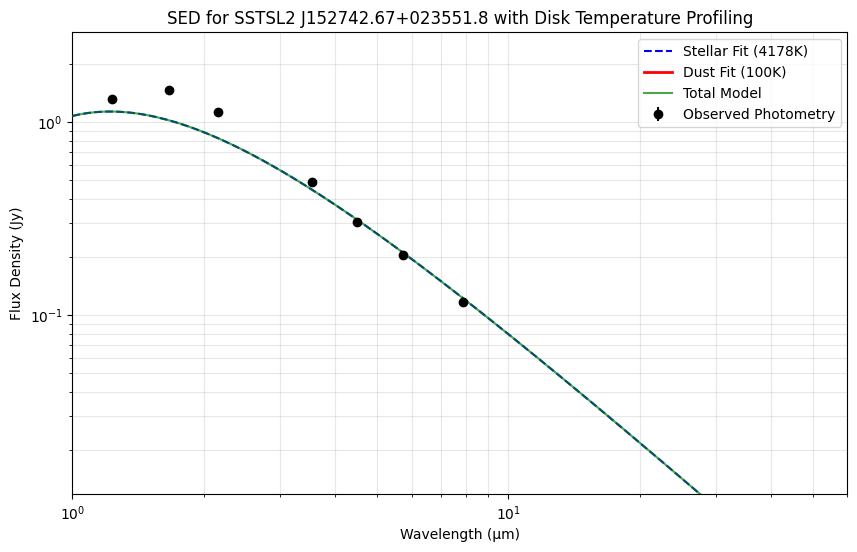

In [ ]:
import matplotlib.pyplot as plt
from astropy.modeling.models import BlackBody
from astropy import units as u
from scipy.optimize import curve_fit
import numpy as np

# 1. Select the first candidate
target_star = k_dwarfs.iloc[0]
target_name = target_star['objid']
t_eff_est = target_star['estimated_teff']

print(f"Processing Target: {target_name}")
print(f"Estimated Teff: {t_eff_est:.1f} K")

# 2. Extract photometric data (Fluxes in uJy converted to Jy)
wave_centers = np.array([1.235, 1.662, 2.159, 3.55, 4.49, 5.73, 7.87])
flux_cols = ['j', 'h', 'k', 'i1_f_ap2', 'i2_f_ap2', 'i3_f_ap2', 'i4_f_ap2']

obs_flux_jy = []
obs_err_jy = []
valid_waves = []

for i, col in enumerate(flux_cols):
    if col in target_star and target_star[col] > 0:
        obs_flux_jy.append(target_star[col] * 1e-6)
        err_col = col.replace('_f_', '_df_') if '_f_' in col else 'd' + col
        err = target_star.get(err_col, target_star[col] * 0.1) * 1e-6
        obs_err_jy.append(err if err > 0 else target_star[col] * 0.1 * 1e-6)
        valid_waves.append(wave_centers[i])

obs_flux_jy = np.array(obs_flux_jy)
obs_err_jy = np.array(obs_err_jy)
valid_waves = np.array(valid_waves)

# 3. Updated SED Model with solid angle
def sed_model(w_um, c_star, c_dust, t_dust):
    # c_star and c_dust now act as the solid angle Omega
    bb_star = BlackBody(temperature=t_eff_est * u.K)
    f_star = (bb_star(w_um * u.micron) * c_star * u.sr).to(u.Jy, u.spectral_density(w_um * u.micron)).value

    bb_dust = BlackBody(temperature=t_dust * u.K)
    f_dust = (bb_dust(w_um * u.micron) * c_dust * u.sr).to(u.Jy, u.spectral_density(w_um * u.micron)).value

    return f_star + f_dust

# Fit the data
try:
    # Initial guesses for Omega (solid angle) and Temperature
    popt, _ = curve_fit(sed_model, valid_waves, obs_flux_jy, p0=[1e-18, 1e-21, 500],
                        bounds=([0, 0, 100], [np.inf, np.inf, 1500]), sigma=obs_err_jy)
    c_star_fit, c_dust_fit, t_dust_fit = popt
except Exception as e:
    print(f"Fit failed: {e}")
    c_star_fit, c_dust_fit, t_dust_fit = 1e-18, 0, 0

# 4. Plotting
# Extend wl_grid to show the full disk curve into the far-IR
wl_grid = np.logspace(0, 1.8, 150)
bb_star_mod = BlackBody(temperature=t_eff_est * u.K)
star_flux = (bb_star_mod(wl_grid * u.micron) * c_star_fit * u.sr).to(u.Jy, u.spectral_density(wl_grid * u.micron)).value

plt.figure(figsize=(10, 6))
plt.errorbar(valid_waves, obs_flux_jy, yerr=obs_err_jy, fmt='ko', label='Observed Photometry', zorder=5)
plt.plot(wl_grid, star_flux, 'b--', label=f'Stellar Fit ({t_eff_est:.0f}K)', zorder=2)

if c_dust_fit > 0:
    bb_dust_mod = BlackBody(temperature=t_dust_fit * u.K)
    dust_flux = (bb_dust_mod(wl_grid * u.micron) * c_dust_fit * u.sr).to(u.Jy, u.spectral_density(wl_grid * u.micron)).value
    plt.plot(wl_grid, dust_flux, 'r-', linewidth=2, label=f'Dust Fit ({t_dust_fit:.0f}K)', zorder=3)
    plt.plot(wl_grid, star_flux + dust_flux, 'g-', alpha=0.7, label='Total Model', zorder=4)

    # Calculate and show necessary temperature ranges along the disk line
    # Using Wien's Displacement Law approximation: T = 2898 / lambda
    wavelen_points = [3.5, 5.0, 10.0, 20.0, 40.0]
    for w_val in wavelen_points:
        if wl_grid.min() <= w_val <= wl_grid.max():
            # Interpolate to find the exact flux value on the plotted curve
            f_val = np.interp(w_val, wl_grid, dust_flux)
            t_val = 2898.0 / w_val

            # Plot a marker and annotate the temperature
            plt.plot(w_val, f_val, 'r.', markersize=10)
            plt.annotate(f"{t_val:.0f}K", xy=(w_val, f_val), xytext=(0, 12),
                         textcoords='offset points', ha='center', va='bottom',
                         color='darkred', fontsize=10, fontweight='bold',
                         arrowprops=dict(arrowstyle="-", color='darkred', alpha=0.6))

plt.xscale('log')
plt.yscale('log')
# Adjust axis limits to clearly see the annotations
plt.xlim(1, 60)
plt.ylim(min(obs_flux_jy)*0.1, max(obs_flux_jy)*2)
plt.xlabel('Wavelength (μm)')
plt.ylabel('Flux Density (Jy)')
plt.title(f'SED for {target_name} with Disk Temperature Profiling')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()


### Infrared Excess Analysis
We calculate the residuals between the observed data and the stellar component to see if there is significant excess at longer wavelengths.

Infrared Excess Analysis for SSTSL2 J152742.67+023551.8:


,Wavelength (um),Observed Flux (Jy),Stellar Model (Jy),Residual (Jy),Fractional Excess (%)
0,1.235,1.3170,1.138419,0.178581,15.686788
1,1.662,1.4710,1.026599,0.444401,43.288720
2,2.159,1.1340,0.827383,0.306617,37.058681
3,3.550,0.4917,0.446334,0.045366,10.164174
4,4.490,0.3043,0.313345,-0.009045,-2.886664
5,5.730,0.2047,0.211019,-0.006319,-2.994461
6,7.870,0.1175,0.122242,-0.004742,-3.879553


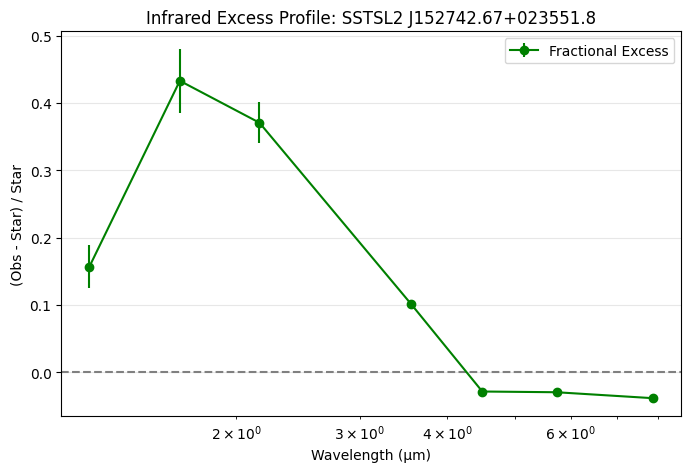

In [ ]:
import pandas as pd

# 1. Calculate the Stellar-only flux at the observed wavelengths
bb_star_eval = BlackBody(temperature=t_eff_est * u.K)
stellar_flux_at_obs = (bb_star_eval(valid_waves * u.micron) * c_star_fit * u.sr).to(u.Jy, u.spectral_density(valid_waves * u.micron)).value

# 2. Compute Residuals and Fractional Excess
residuals = obs_flux_jy - stellar_flux_at_obs
fractional_excess = residuals / stellar_flux_at_obs

# 3. Display as a Table
excess_results = pd.DataFrame({
    'Wavelength (um)': valid_waves,
    'Observed Flux (Jy)': obs_flux_jy,
    'Stellar Model (Jy)': stellar_flux_at_obs,
    'Residual (Jy)': residuals,
    'Fractional Excess (%)': fractional_excess * 100
})

print(f"Infrared Excess Analysis for {target_name}:")
display(excess_results)

# 4. Plot Residuals
plt.figure(figsize=(8, 5))
plt.axhline(0, color='gray', linestyle='--')
plt.errorbar(valid_waves, fractional_excess, yerr=obs_err_jy/stellar_flux_at_obs, fmt='go-', label='Fractional Excess')
plt.xlabel('Wavelength (μm)')
plt.ylabel('(Obs - Star) / Star')
plt.title(f'Infrared Excess Profile: {target_name}')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import requests
from astropy.io import ascii
import io

def query_irsa_scs(ra, dec, table="seip", radius_arcsec=10):
    """
    General IRSA Simple Cone Search query.
    """
    url = "https://irsa.ipac.caltech.edu/SCS"
    params = {
        "table": table,
        "ra": ra,
        "dec": dec,
        "radius": radius_arcsec / 3600.0,
        "formatter": "csv"
    }
    r = requests.get(url, params=params)
    if r.status_code == 200:
        content = r.text.strip()
        if not content or "No data found" in content or "error" in content.lower():
            return None
        try:
            return ascii.read(io.StringIO(content), format='csv')
        except:
            return None
    return None

# Coordinates for KIC 8278402 (Skorpen et al. 2024)
ra_kic, dec_kic = 281.78763, 44.21824

# Try querying the main SEIP source list
data = query_irsa_scs(ra_kic, dec_kic, table="seip")

if data and len(data) > 0:
    print(f"--- Data Found for KIC 8278402 ---")
    # Display first row of relevant columns if they exist
    cols_to_show = [c for c in ['ra', 'dec', 'i1_f_ap2', 'i2_f_ap2', 'i3_f_ap2', 'i4_f_ap2', 'm1_f_psf'] if c in data.colnames]
    display(data[cols_to_show][0:1])
else:
    print("Still no data found in SEIP for these coordinates. We may need to query VizieR for this specific target.")

Still no data found in SEIP for these coordinates. We may need to query VizieR for this specific target.


In [ ]:
!pip install -q astroquery

from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as u

# 1. Define target coordinates
coord = SkyCoord(ra=281.78763, dec=44.21824, unit=(u.deg, u.deg), frame='icrs')

# 2. Query VizieR for KIC and AllWISE
# V/133: Kepler Input Catalog
# II/328: AllWISE Data Release
v = Vizier(columns=['*', '+_r'], catalog=['V/133', 'II/328'])
result = v.query_region(coord, radius=5*u.arcsec)

print(f"--- VizieR Query Results for KIC 8278402 ---")
if result:
    for table_name in result.keys():
        print(f"\nTable: {table_name}")
        display(result[table_name].to_pandas().head(1))
else:
    print("No matches found in VizieR for KIC or AllWISE within 5 arcsec.")

--- VizieR Query Results for KIC 8278402 ---

Table: V/133/kic


,_r,KIC,RAJ2000,DEJ2000,umag,gmag,rmag,imag,Jmag,Kmag,kepmag,sg,v,aq,fv
0,0.028,8278402,281.78763,44.218239,NaN,16.063,15.503,15.329,14.429,14.034,15.549,0,0,6,2



Table: II/328/allwise


,_r,AllWISE,RAJ2000,DEJ2000,Im,W1mag,e_W1mag,W2mag,e_W2mag,W3mag,...,ccf,ex,var,pmRA,e_pmRA,pmDE,e_pmDE,qph,d2M,2M
0,0.082,J184709.02+441305.6,281.787604,44.21824,Im,13.945,0.025,14.0,0.032,13.167,...,0000,0,00nn,-76,79,-33,82,AAUU,0.041,2M


Starting processing for 3 stars...



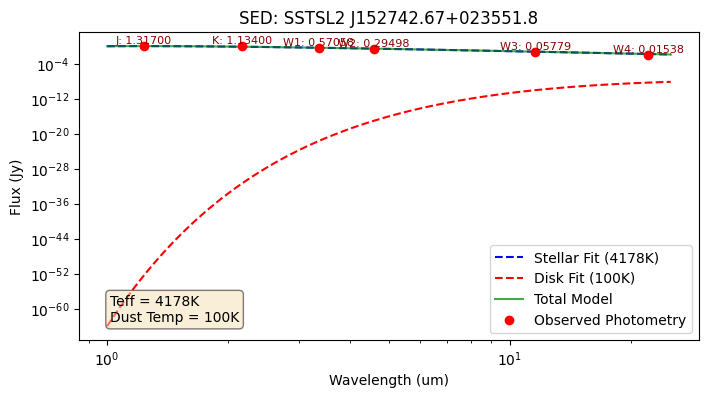

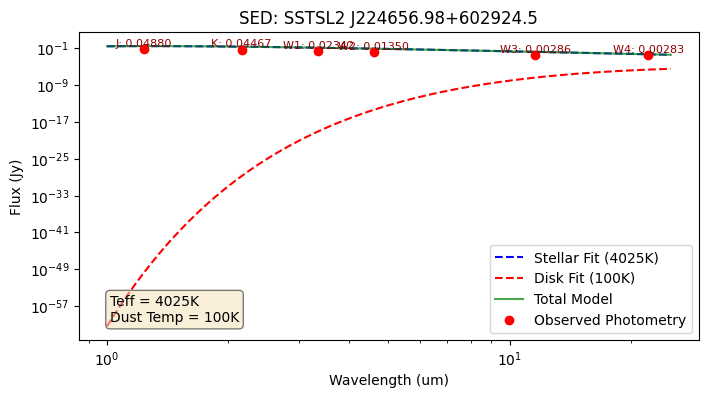

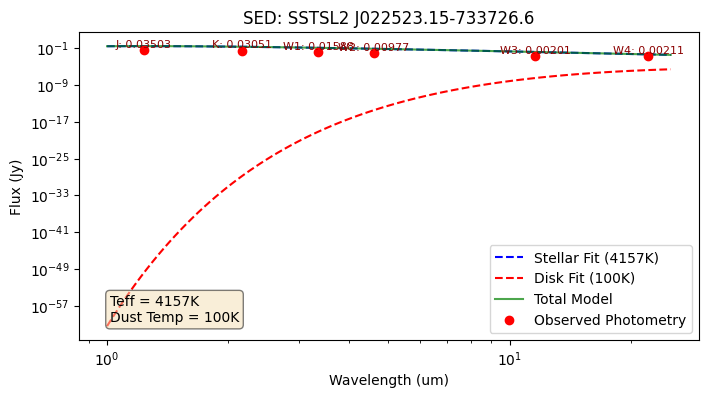

Saved results to /content/SED_Processed_Results.csv


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import BlackBody
from astropy import units as u
from scipy.optimize import curve_fit
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import pandas as pd
import time

# 1. Load the available dataset
k_dwarfs = pd.read_csv('/content/K_Dwarfs_3k.csv')

# Create directory for plots
plot_dir = '/content/SED_plots'
os.makedirs(plot_dir, exist_ok=True)

# 2. Configuration for Bulk Processing
num_stars = 3
v = Vizier(columns=['*', '+_r'], catalog=['II/328'])

def get_sed_data(ra, dec):
    coord = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg), frame='icrs')
    try:
        result = v.query_region(coord, radius=10*u.arcsec)
        if result and len(result) > 0:
            return result[0]
    except Exception:
        return None
    return None

# 3. Loop through candidates
processed_count = 0
results_list = []
print(f"Starting processing for {num_stars} stars...\n")

for i in range(len(k_dwarfs)):
    if processed_count >= num_stars: break

    star = k_dwarfs.iloc[i]
    obj_id = star['objid']
    ra, dec = star['ra'], star['dec']
    t_eff_val = star.get('estimated_teff', 4500)
    j_mag_val = star.get('j_mag')
    k_mag_val = star.get('k_mag')

    res_table = get_sed_data(ra, dec)
    if res_table is None: continue

    try:
        phot_data = [
            {'band': 'J', 'wave': 1.235, 'mag': j_mag_val, 'zp': 1594.0},
            {'band': 'K', 'wave': 2.159, 'mag': k_mag_val, 'zp': 666.8},
            {'band': 'W1', 'wave': 3.35, 'mag': res_table['W1mag'][0], 'zp': 309.54},
            {'band': 'W2', 'wave': 4.60, 'mag': res_table['W2mag'][0], 'zp': 171.79},
            {'band': 'W3', 'wave': 11.56, 'mag': res_table['W3mag'][0], 'zp': 31.67},
            {'band': 'W4', 'wave': 22.09, 'mag': res_table['W4mag'][0], 'zp': 8.36}
        ]

        real_waves = np.array([p['wave'] for p in phot_data if not np.isnan(p['mag'])])
        real_flux_jy = np.array([p['zp'] * 10**(-0.4 * p['mag']) for p in phot_data if not np.isnan(p['mag'])])

        if len(real_waves) < 4: continue

        def photosphere_only(w_um, c_star):
            bb_star = BlackBody(temperature=t_eff_val * u.K)
            return (bb_star(w_um * u.micron) * c_star * u.sr).to(u.Jy, u.spectral_density(w_um * u.micron)).value

        def sed_model_full(w_um, c_star, c_dust, t_dust):
            bb_star = BlackBody(temperature=t_eff_val * u.K)
            f_star = (bb_star(w_um * u.micron) * c_star * u.sr).to(u.Jy, u.spectral_density(w_um * u.micron)).value
            bb_dust = BlackBody(temperature=t_dust * u.K)
            f_dust = (bb_dust(w_um * u.micron) * c_dust * u.sr).to(u.Jy, u.spectral_density(w_um * u.micron)).value
            return f_star + f_dust

        popt_star, _ = curve_fit(photosphere_only, real_waves[:2], real_flux_jy[:2], p0=[1e-19])
        cs_fixed = popt_star[0]

        try:
            popt_full, _ = curve_fit(sed_model_full, real_waves, real_flux_jy, p0=[cs_fixed, 1e-21, 500],
                                     bounds=([0, 0, 100], [np.inf, np.inf, 1500]))
            c_star_fit, c_dust_fit, t_dust_fit = popt_full
        except Exception:
            c_star_fit, c_dust_fit, t_dust_fit = cs_fixed, 0, 0

        plt.figure(figsize=(8, 4))
        wl_grid = np.logspace(0, 1.4, 100)

        # Plot components
        star_flux = photosphere_only(wl_grid, c_star_fit)
        plt.plot(wl_grid, star_flux, 'b--', label=f'Stellar Fit ({t_eff_val:.0f}K)')

        if c_dust_fit > 0:
            bb_dust_mod = BlackBody(temperature=t_dust_fit * u.K)
            dust_flux = (bb_dust_mod(wl_grid * u.micron) * c_dust_fit * u.sr).to(u.Jy, u.spectral_density(wl_grid * u.micron)).value
            plt.plot(wl_grid, dust_flux, 'r--', label=f'Disk Fit ({t_dust_fit:.0f}K)')
            plt.plot(wl_grid, star_flux + dust_flux, 'g-', alpha=0.7, label='Total Model')

        for i_p, p in enumerate(phot_data):
            if not np.isnan(p['mag']):
                flux = p['zp'] * 10**(-0.4 * p['mag'])
                lbl = 'Observed Photometry' if i_p == 0 else "_nolegend_"
                plt.plot(p['wave'], flux, 'ro', label=lbl)
                # Add value annotation above the dot
                plt.text(p['wave'], flux * 1.2, f"{p['band']}: {flux:.5f}", fontsize=8, color='darkred', ha='center', va='bottom')

        plt.xscale('log'); plt.yscale('log')
        plt.title(f"SED: {obj_id}")
        plt.xlabel("Wavelength (um)"); plt.ylabel("Flux (Jy)")

        # Add info box
        info_text = f"Teff = {t_eff_val:.0f}K\nDust Temp = {t_dust_fit:.0f}K"
        plt.text(0.05, 0.05, info_text, transform=plt.gca().transAxes, fontsize=10,
                 verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.legend(loc='lower right')

        safe_obj_id = obj_id.replace(" ", "_").replace("+", "_").replace("-", "_")
        plot_filename = f"{plot_dir}/SED_{safe_obj_id}.png"
        plt.savefig(plot_filename)
        plt.show()

        results_list.append({
            'objid': obj_id, 'ra': ra, 'dec': dec, 'teff': t_eff_val,
            'dust_temp': t_dust_fit, 'plot_file': plot_filename
        })

        processed_count += 1
        time.sleep(0.5)
    except Exception:
        continue

# Save the extracted dataset
if results_list:
    results_df = pd.DataFrame(results_list)
    results_df.to_csv('/content/SED_Processed_Results.csv', index=False)
    print("Saved results to /content/SED_Processed_Results.csv")


In [7]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display
from astropy.modeling.models import BlackBody
from astropy import units as u
from scipy.optimize import curve_fit

def run_bulk_sed_generator(csv_path='/content/K_Dwarfs_3k.csv', output_dir='/content/SED_plots', output_csv='/content/SED_Bulk_Results.csv', max_targets=10):
    """
    Generates SED Multi-Component Plots for multiple targets checking for infrared excess
    at the 4.5 micron (I2) point relative to the stellar photosphere, and fits a dust disk.
    """
    print("==================================================")
    print(f"STARTING BULK SED GENERATOR (Max Targets: {max_targets})")
    print("==================================================\n")

    if not os.path.exists(csv_path):
        print(f"ERROR: Dataset {csv_path} not found.")
        return

    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset with {len(df)} targets. Processing...")

    results = []

    for idx, row in df.iterrows():
        if idx >= max_targets:
            print(f"\nReached maximum limit of {max_targets} targets. Stopping early.")
            break

        active_id = row.get('objid', f'Target_{idx}')
        print(f"Processing target {idx+1}: {active_id}")

        bands = {
            'I1 (3.6 \u00b5m)': (3.6, row.get('i1_f_ap2', np.nan)),
            'I2 (4.5 \u00b5m)': (4.5, row.get('i2_f_ap2', np.nan)),
            'I3 (5.8 \u00b5m)': (5.8, row.get('i3_f_ap2', np.nan)),
            'I4 (8.0 \u00b5m)': (8.0, row.get('i4_f_ap2', np.nan)),
            'MIPS1 (24 \u00b5m)': (24.0, row.get('m1_f_ap2', np.nan))
        }

        valid_bands = {k: v for k, v in bands.items() if pd.notna(v[1]) and v[1] > 0}

        if len(valid_bands) < 2:
            print(f"  -> Skipping {active_id}: Not enough valid photometric points.")
            results.append({'objid': active_id, 'status': 'Skipped (Not enough data)', 'excess_pct': np.nan, 'plot_path': None})
            continue

        wavs = np.array([v[0] for v in valid_bands.values()])
        fluxes = np.array([v[1] for v in valid_bands.values()])
        labels = list(valid_bands.keys())

        anchor_wav = wavs[0]
        anchor_flux = fluxes[0]

        simulated_wavs = np.linspace(min(wavs) * 0.9, max(wavs) * 1.1, 100)
        photosphere_flux = anchor_flux * (simulated_wavs / anchor_wav)**(-2)

        # Blackbody curve based on Teff
        teff = row.get('estimated_teff', 4500)
        bb = BlackBody(temperature=teff * u.K)
        bb_sim_fluxes = bb(simulated_wavs * u.micron).value
        bb_anchor = bb(anchor_wav * u.micron).value
        bb_normalized = bb_sim_fluxes * (anchor_flux / bb_anchor)

        fig = plt.figure(figsize=(10, 6))
        plt.plot(simulated_wavs, photosphere_flux, 'k--', linewidth=2, label='Fitted Stellar Photosphere (RJ Tail)', zorder=1)
        plt.plot(simulated_wavs, bb_normalized, 'b:', linewidth=2, label=f'Stellar BB ({teff:.0f}K)', zorder=2)

        # Disk component fitting
        bb_obs_fluxes = bb(wavs * u.micron).value * (anchor_flux / bb_anchor)
        residuals = fluxes - bb_obs_fluxes

        def dust_model(w, t_dust, c_dust):
            b = BlackBody(temperature=t_dust * u.K)
            return b(w * u.micron).value * c_dust

        disk_plotted = False
        dust_temp_fit = np.nan
        if len(wavs[residuals > 0]) >= 2:
            try:
                popt, _ = curve_fit(dust_model, wavs[residuals > 0], residuals[residuals > 0],
                                    p0=[300, 1e-15], bounds=([50, 0], [1500, np.inf]))
                dust_temp_fit, c_dust_fit = popt
                disk_fluxes = dust_model(simulated_wavs, dust_temp_fit, c_dust_fit)
                plt.plot(simulated_wavs, disk_fluxes, 'r--', linewidth=2, label=f'Disk BB Fit ({dust_temp_fit:.0f}K)', zorder=3)
                plt.plot(simulated_wavs, bb_normalized + disk_fluxes, 'g-', linewidth=1.5, alpha=0.6, label='Total Model', zorder=4)

                # Show value along the disk line
                peak_idx = np.argmax(disk_fluxes)
                plt.annotate(f'T_dust ~ {dust_temp_fit:.0f}K',
                             xy=(simulated_wavs[peak_idx], disk_fluxes[peak_idx]),
                             xytext=(10, 10), textcoords='offset points', color='red', fontsize=10,
                             arrowprops=dict(arrowstyle="->", color='red'))
                disk_plotted = True
            except Exception as e:
                print(f"  -> Disk fit failed for {active_id}: {e}")

        plt.scatter(wavs, fluxes, color='red', s=80, edgecolor='black', label='Observed Photometry', zorder=5)

        excess_pct = np.nan
        if 'I2 (4.5 \u00b5m)' in valid_bands:
            i2_wav, i2_flux = valid_bands['I2 (4.5 \u00b5m)']
            expected_i2_flux = anchor_flux * (4.5 / anchor_wav)**(-2)
            excess_pct = ((i2_flux - expected_i2_flux) / expected_i2_flux) * 100
            plt.scatter([4.5], [i2_flux], color='gold', s=250, marker='*', edgecolor='black', zorder=6, label=f'I2 Point (Stat. Excess: {excess_pct:.1f}%)')
            plt.plot([4.5, 4.5], [expected_i2_flux, i2_flux], 'g-', linewidth=2, zorder=4, alpha=0.7)

        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Wavelength (\u00b5m)', fontsize=12)
        plt.ylabel('Flux Density $F_\nu$ (\u00b5Jy)', fontsize=12)
        plt.title(f'SED Multi-Component Plot for {active_id}', fontsize=14, fontweight='bold')
        plt.grid(True, which="both", ls="--", alpha=0.3)
        plt.xticks([3.6, 4.5, 5.8, 8.0, 24.0], ['3.6', '4.5', '5.8', '8.0', '24.0'])

        for i, txt in enumerate(labels):
            plt.annotate(txt, (wavs[i], fluxes[i]), xytext=(7, 7), textcoords='offset points', fontsize=9)

        plt.legend(loc='lower left')
        plt.tight_layout()

        safe_id = str(active_id).replace(" ", "_").replace("+", "_").replace("-", "_")
        plot_filename = os.path.join(output_dir, f"SED_{safe_id}.png")
        plt.savefig(plot_filename)
        plt.close(fig)

        results.append({
            'objid': active_id,
            'status': 'Processed',
            'excess_pct': excess_pct,
            'dust_temp': dust_temp_fit if disk_plotted else np.nan,
            'plot_path': plot_filename
        })

    # Save results to a new dataset
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_csv, index=False)

    print("\n" + "="*50)
    print("BULK GENERATION COMPLETE")
    print("="*50)
    print(f"Plots saved to: {output_dir}")
    print(f"Results summary saved to: {output_csv}")

if __name__ == "__main__":
    # Run the bulk pipeline. Set max_targets to a larger number (e.g., len(df)) to process the whole dataset.
    run_bulk_sed_generator(csv_path='/content/K_Dwarfs_3k.csv', max_targets=10)


STARTING BULK SED GENERATOR (Max Targets: 10)

ERROR: Dataset /content/K_Dwarfs_3k.csv not found.


In [4]:
import os
import IPython.display as display

plot_dir = '/content/SED_plots_full'
if os.path.exists(plot_dir):
    image_files = [f for f in os.listdir(plot_dir) if f.endswith('.png')]
    print(f"Found {len(image_files)} plots in {plot_dir}:\n")

    for img_file in sorted(image_files):
        print(f"--- {img_file} ---")
        display.display(display.Image(filename=os.path.join(plot_dir, img_file)))
else:
    print(f"Directory {plot_dir} not found.")

Directory /content/SED_plots_full not found.


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as display
from astropy.modeling.models import BlackBody
from astropy import units as u
from scipy.optimize import curve_fit

def run_bulk_sed_generator_updated(csv_path='/content/SEIP117k_1k_kdwarfs_filtered.csv', output_dir='/content/SED_plots_v2', output_csv='/content/SED_Bulk_Results_v2.csv', max_targets=10):
    """
    Generates SED Multi-Component Plots for multiple targets checking for infrared excess
    at the 4.5 micron (I2) point relative to the stellar photosphere, and fits a dust disk.
    """
    print("==================================================")
    print(f"STARTING BULK SED GENERATOR (Max Targets: {max_targets})")
    print("==================================================\n")

    if not os.path.exists(csv_path):
        print(f"ERROR: Dataset {csv_path} not found.")
        return

    os.makedirs(output_dir, exist_ok=True)
    df = pd.read_csv(csv_path)
    print(f"Loaded dataset with {len(df)} targets. Processing...")

    results = []

    for idx, row in df.iterrows():
        if max_targets is not None and idx >= max_targets:
            print(f"\nReached maximum limit of {max_targets} targets. Stopping early.")
            break

        active_id = row.get('objid', f'Target_{idx}')
        ra_val = row.get('ra', np.nan)
        dec_val = row.get('dec', np.nan)

        print(f"Processing target {idx+1}: {active_id}")

        mips_raw_val = row.get('m1_f_ap2', np.nan)

        bands = {
            'I1 (3.6 \u00b5m)': (3.6, row.get('i1_f_ap2', np.nan)),
            'I2 (4.5 \u00b5m)': (4.5, row.get('i2_f_ap2', np.nan)),
            'I3 (5.8 \u00b5m)': (5.8, row.get('i3_f_ap2', np.nan)),
            'I4 (8.0 \u00b5m)': (8.0, row.get('i4_f_ap2', np.nan)),
            'MIPS1 (24 \u00b5m)': (24.0, mips_raw_val)
        }

        valid_bands = {k: v for k, v in bands.items() if pd.notna(v[1]) and v[1] > 0}

        if len(valid_bands) < 2:
            print(f"  -> Skipping {active_id}: Not enough valid photometric points.")
            results.append({'objid': active_id, 'ra': ra_val, 'dec': dec_val, 'status': 'Skipped (Not enough data)', 'excess_pct': np.nan, 'dust_temp': np.nan, 'plot_path': None})
            continue

        wavs = np.array([v[0] for v in valid_bands.values()])
        # Keep fluxes in microJanskys (uJy)
        fluxes = np.array([v[1] for v in valid_bands.values()])
        labels = list(valid_bands.keys())

        anchor_wav = wavs[0]
        anchor_flux = fluxes[0]

        simulated_wavs = np.logspace(np.log10(min(wavs) * 0.8), np.log10(max(40, max(wavs) * 1.5)), 200)
        photosphere_flux = anchor_flux * (simulated_wavs / anchor_wav)**(-2)

        # Blackbody curve based on Teff
        teff = row.get('estimated_teff', 4500)
        bb = BlackBody(temperature=teff * u.K)
        bb_sim_fluxes = bb(simulated_wavs * u.micron).value
        bb_anchor = bb(anchor_wav * u.micron).value
        bb_normalized = bb_sim_fluxes * (anchor_flux / bb_anchor)

        fig, ax = plt.subplots(figsize=(8, 6))

        # Plot Stellar Components
        ax.plot(simulated_wavs, photosphere_flux, color='gray', linestyle=':', linewidth=1.5, label='Stellar Photosphere (RJ Tail)', zorder=1)
        ax.plot(simulated_wavs, bb_normalized, color='blue', linestyle='--', linewidth=1.5, label=f'Stellar BB ({teff:.0f} K)', zorder=2)

        # Fetch and plot theoretical spectrum
        wave_model, flux_model = fetch_theoretical_spectrum(teff)
        if wave_model is not None:
            # Interpolate model flux at the anchor wavelength for normalization
            model_anchor_flux = np.interp(anchor_wav, wave_model, flux_model)
            if model_anchor_flux > 0:
                model_normalized = flux_model * (anchor_flux / model_anchor_flux)
                # Filter spectrum roughly to plot limits to avoid huge unplotted data arrays
                mask = (wave_model >= min(simulated_wavs)*0.8) & (wave_model <= max(simulated_wavs)*1.5)
                ax.plot(wave_model[mask], model_normalized[mask], color='cyan', linestyle='-', linewidth=1.5, alpha=0.7, label=f'BT-Settl ({teff:.0f} K)', zorder=1.5)

        # Disk component fitting
        bb_obs_fluxes = bb(wavs * u.micron).value * (anchor_flux / bb_anchor)
        residuals = fluxes - bb_obs_fluxes

        def dust_model(w, t_dust, c_dust):
            b = BlackBody(temperature=t_dust * u.K)
            return b(w * u.micron).value * c_dust

        disk_plotted = False
        dust_temp_fit = np.nan
        if len(wavs[residuals > 0]) >= 2:
            try:
                # Adjust p0 for c_dust since fluxes are now in uJy (1e6 larger than Jy)
                popt, _ = curve_fit(dust_model, wavs[residuals > 0], residuals[residuals > 0],
                                    p0=[300, 1e-9], bounds=([50, 0], [1500, np.inf]))
                dust_temp_fit, c_dust_fit = popt
                disk_fluxes = dust_model(simulated_wavs, dust_temp_fit, c_dust_fit)

                ax.plot(simulated_wavs, disk_fluxes, color='red', linestyle='--', linewidth=1.5, label=f'Disk BB Fit ({dust_temp_fit:.0f} K)', zorder=3)
                ax.plot(simulated_wavs, bb_normalized + disk_fluxes, color='black', linestyle='-', linewidth=2, alpha=0.9, label='Total Model', zorder=4)
                disk_plotted = True
            except Exception as e:
                print(f"  -> Disk fit failed for {active_id}: {e}")

        # Plot General Photometry backbone (now Red as requested)
        ax.errorbar(wavs, fluxes, yerr=fluxes*0.05, fmt='o', color='red', markerfacecolor='red', markeredgecolor='black', markeredgewidth=1.0, markersize=7, label='Observed Photometry', zorder=5)

        # Add specific annotations and highlights for each band
        excess_pct = np.nan
        expected_i2_flux = np.nan
        i2_f_ujy = np.nan

        for band_name, (w, f_ujy) in valid_bands.items():
            short_name = band_name.split()[0] # e.g., 'I1', 'MIPS1'

            if 'MIPS' in band_name:
                # Make MIPS very prominent and move label away
                ax.plot(w, f_ujy, marker='o', color='red', markeredgecolor='black', markersize=10, linestyle='None', zorder=8)
                ax.annotate(f"MIPS: {f_ujy:.1f} $\mu$Jy", (w, f_ujy), xytext=(0, -25), textcoords='offset points', ha='center', va='top', color='red', fontsize=10, fontweight='bold')
            elif 'I2' in band_name:
                expected_i2_flux = anchor_flux * (4.5 / anchor_wav)**(-2)
                excess_pct = ((f_ujy - expected_i2_flux) / expected_i2_flux) * 100
                i2_f_ujy = f_ujy
                ax.plot([4.5], [f_ujy], marker='*', color='gold', markeredgecolor='black', markersize=14, linestyle='None', zorder=6, label=f'I2 Excess: {excess_pct:.1f}%')
                ax.annotate(f"{short_name}: {f_ujy:.1f} $\mu$Jy", (w, f_ujy), xytext=(0, 25), textcoords='offset points', ha='center', va='bottom', color='black', fontsize=9)
            else:
                # Move labels away from the line
                ax.annotate(f"{short_name}: {f_ujy:.1f} $\mu$Jy", (w, f_ujy), xytext=(0, 20), textcoords='offset points', ha='center', va='bottom', color='black', fontsize=9)

        # Add IR Excess info box if calculated
        mips_str = f"{mips_raw_val:.1f} $\mu$Jy" if pd.notna(mips_raw_val) and mips_raw_val > 0 else "N/A"
        info_text = (f"MIPS (24 $\mu$m): {mips_str}\n")

        if not np.isnan(excess_pct):
            info_text += (f"Infrared Excess (4.5 $\mu$m):\n"
                         f"$F_{{obs}}$ = {i2_f_ujy:.1f} $\mu$Jy\n"
                         f"$F_{{exp}}$ = {expected_i2_flux:.1f} $\mu$Jy\n"
                         f"Excess = {excess_pct:.1f}%")

        ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

        # Universal Temperature Reference Line
        min_f = min(fluxes)
        max_f = max(fluxes)
        if disk_plotted:
            min_f = min(min_f, min(disk_fluxes[disk_fluxes > 0]) if any(disk_fluxes > 0) else min_f)

        ref_y = min_f * 0.25 # Place it near the bottom
        wavelen_points = np.array([4.0, 6.0, 10.0, 15.0, 24.0, 35.0])
        w_valid = wavelen_points[(wavelen_points >= simulated_wavs.min()) & (wavelen_points <= simulated_wavs.max())]
        if len(w_valid) > 0:
            # Draw the universal temperature line
            ax.plot([w_valid.min(), w_valid.max()], [ref_y, ref_y], color='darkmagenta', linestyle='-', linewidth=1.5, zorder=6, alpha=0.7)
            ax.plot(w_valid, [ref_y]*len(w_valid), marker='D', color='darkmagenta', markersize=6, linestyle='None', zorder=6, label='Wien Temp Reference')
            for w_val in w_valid:
                t_val = 2898.0 / w_val
                ax.annotate(f"{t_val:.0f}K", xy=(w_val, ref_y), xytext=(0, 8),
                             textcoords='offset points', ha='center', va='bottom',
                             color='darkmagenta', fontsize=9, fontweight='bold')

        # Axe Formatting
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize=14)
        ax.set_ylabel(r'Flux Density ($\mu$Jy)', fontsize=14)
        ax.set_title(f'{active_id}', fontsize=14)

        # Ticks styling for a publication look
        ax.tick_params(axis='both', which='major', labelsize=12, direction='in', length=8, width=1.5, bottom=True, top=True, left=True, right=True)
        ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, bottom=True, top=True, left=True, right=True)

        # Dynamically set limits to fit data and annotations
        ax.set_xlim(min(simulated_wavs), max(simulated_wavs))
        ax.set_ylim(min_f * 0.1, max_f * 50) # Increased upper limit for annotations and info box

        # Professional minimal legend
        ax.legend(loc='upper right', fontsize=10, frameon=False)
        plt.tight_layout()

        safe_id = str(active_id).replace(" ", "_").replace("+", "_").replace("-", "_")
        plot_filename = os.path.join(output_dir, f"SED_{safe_id}.png")
        plt.savefig(plot_filename, dpi=150)
        plt.close(fig)

        results.append({
            'objid': active_id,
            'ra': ra_val,
            'dec': dec_val,
            'status': 'Processed',
            'excess_pct': excess_pct,
            'dust_temp': dust_temp_fit if disk_plotted else np.nan,
            'plot_path': plot_filename
        })

    # Save results to a new dataset
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_csv, index=False)

    print("\n" + "="*50)
    print("BULK GENERATION COMPLETE")
    print("="*50)
    print(f"Plots saved to: {output_dir}")
    print(f"Results summary saved to: {output_csv}")

# Run the bulk processing for all targets
run_bulk_sed_generator_updated(
    csv_path='/content/SEIP117k_1k_kdwarfs_filtered.csv',
    output_dir='/content/SED_plots_v2',
    output_csv='/content/SED_Bulk_Results_v2.csv',
    max_targets=None
)


Found 5 plots in /content/SED_plots_v2:

--- SED_SSTSL2_J010741.41_742546.6.png ---


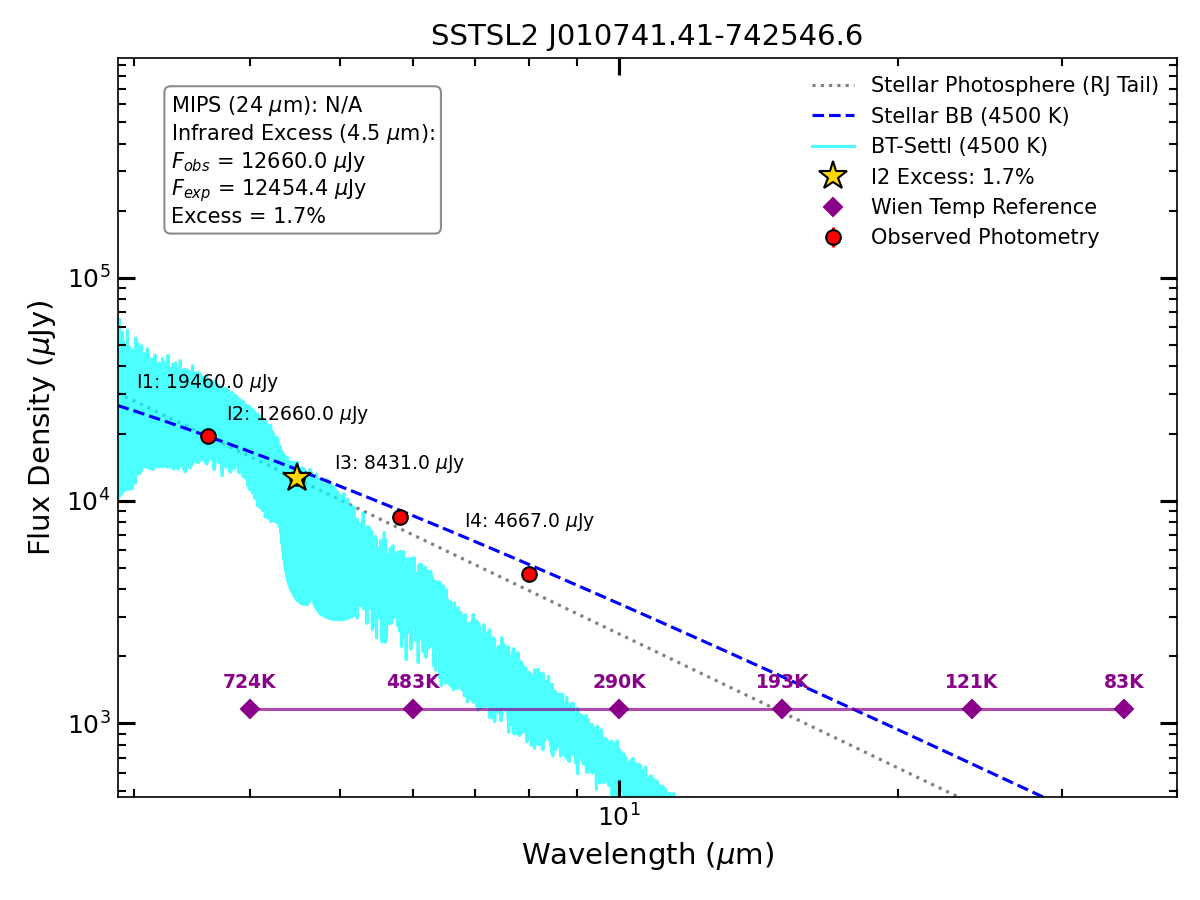

--- SED_SSTSL2_J044516.30_680129.1.png ---


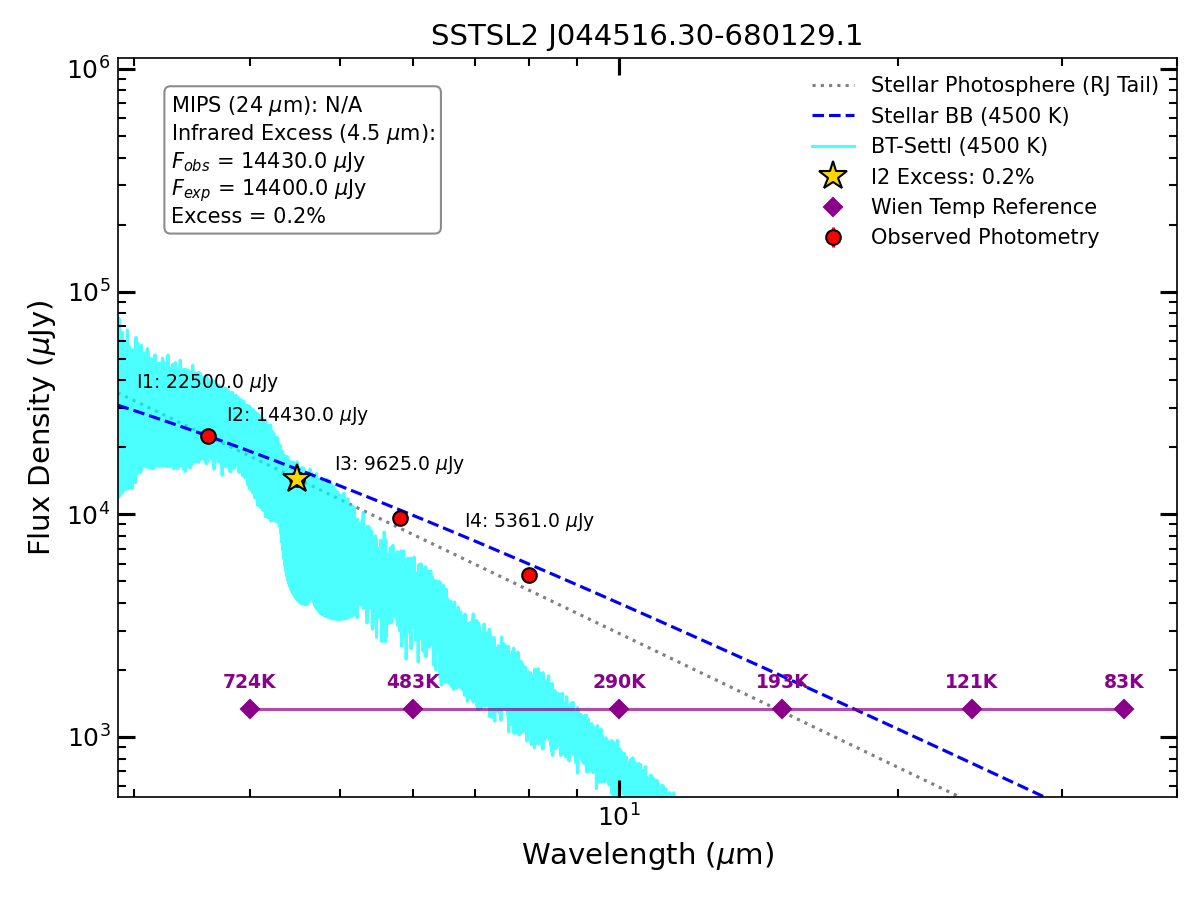

--- SED_SSTSL2_J122150.00_632440.1.png ---


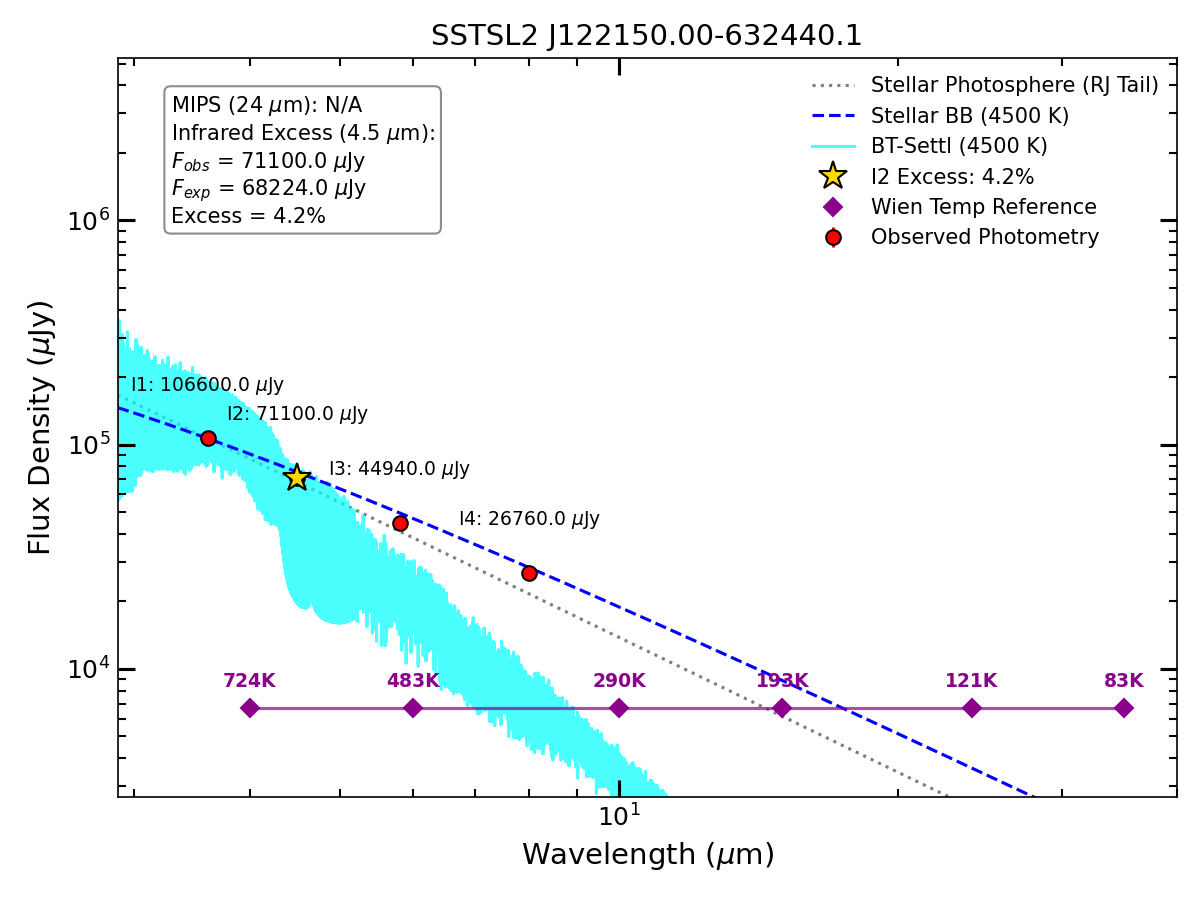

--- SED_SSTSL2_J174731.75_052931.4.png ---


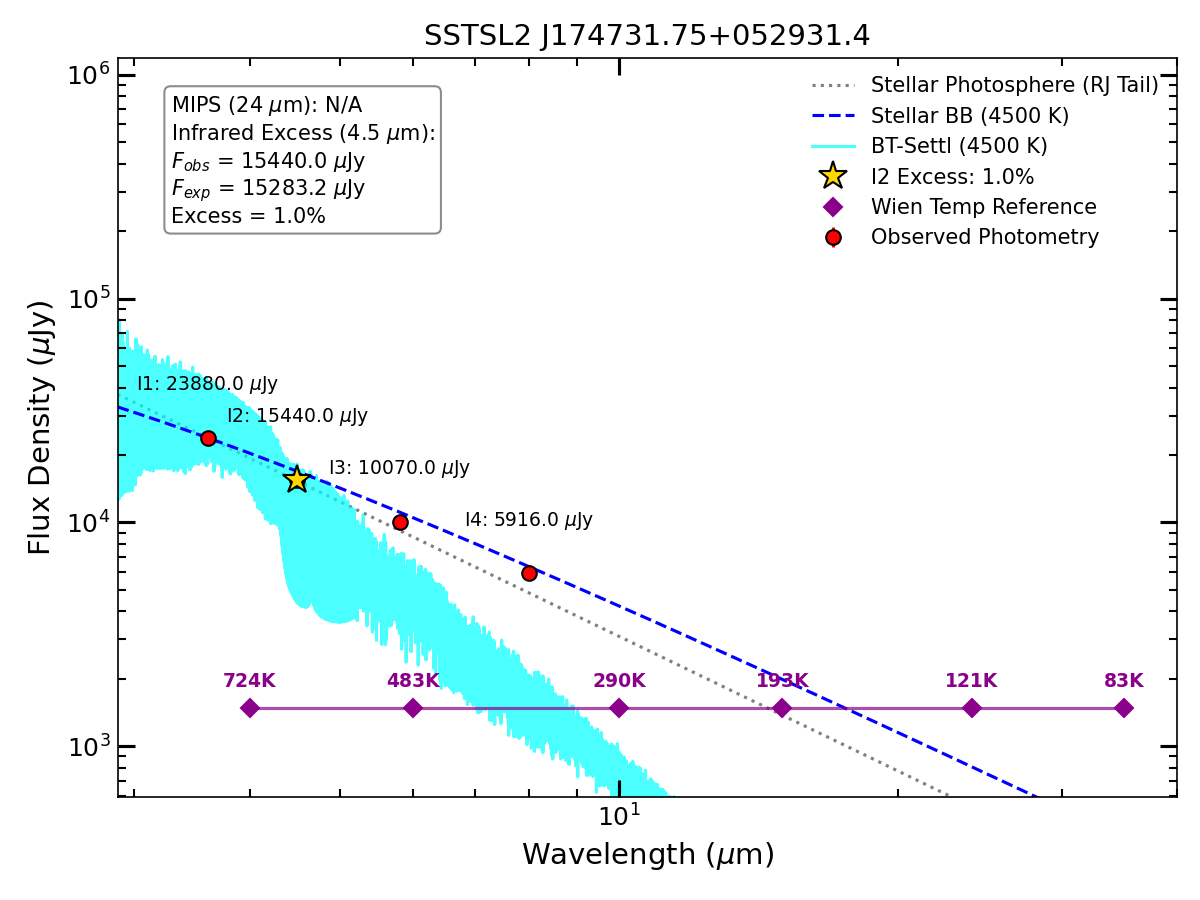

--- SED_SSTSL2_J222424.77_602910.6.png ---


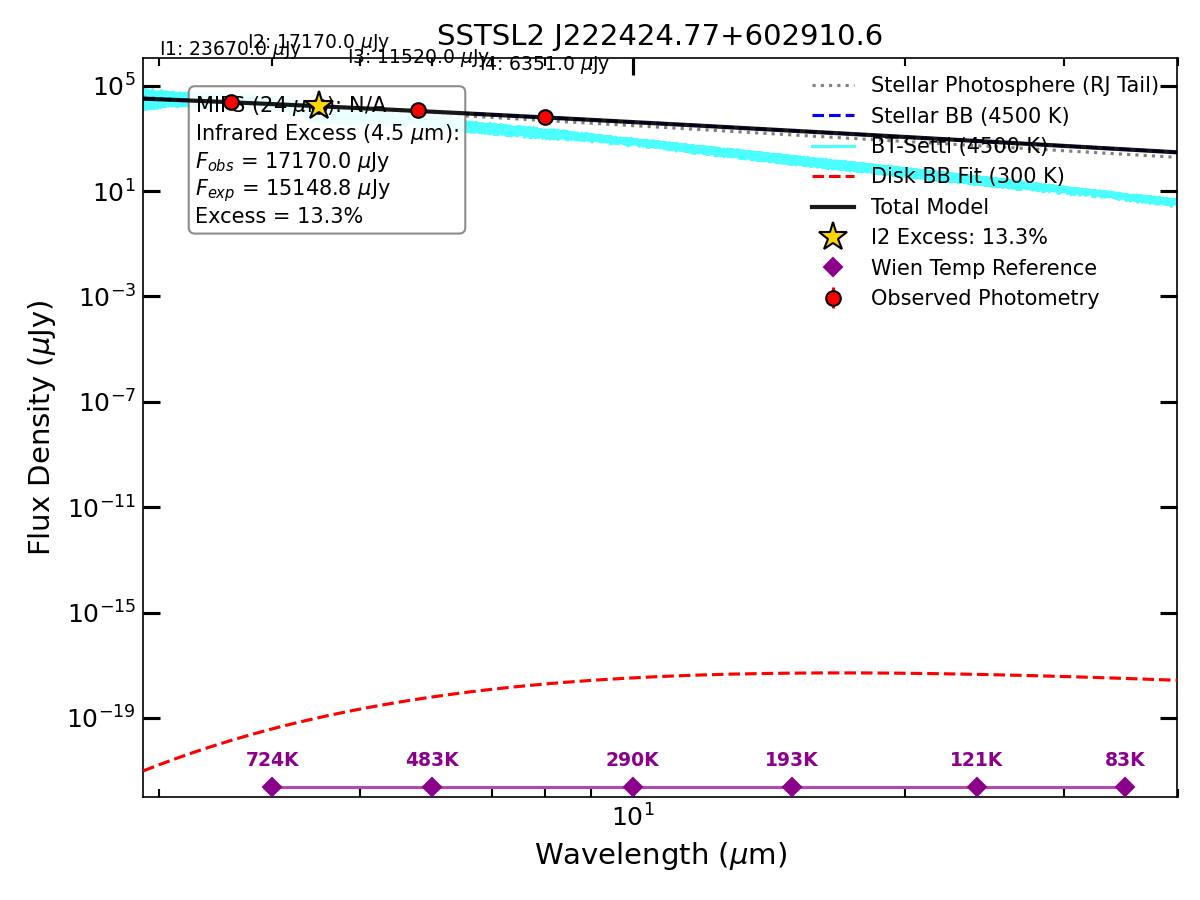

In [37]:
import os
from IPython.display import Image, display

plot_dir = '/content/SED_plots_v2'
if os.path.exists(plot_dir):
    image_files = [f for f in os.listdir(plot_dir) if f.endswith('.png')]
    print(f"Found {len(image_files)} plots in {plot_dir}:\n")

    for img_file in sorted(image_files):
        print(f"--- {img_file} ---")
        # Read as raw bytes to bypass any file-path caching in the browser/notebook
        with open(os.path.join(plot_dir, img_file), 'rb') as f:
            display(Image(data=f.read(), format='png'))
else:
    print(f"Directory {plot_dir} not found. Please make sure the generation step was successful.")


### Fetch NextGen Theoretical Spectrum from SVO
Testing the SSAP connection to retrieve a BT-NextGen model for integration into the SED plots.

Querying SVO SSAP for BT-Settl: Teff=4500K, logg=4.5, [M/H]=0.0...
Spectrum found! Downloading from: http://svo2.cab.inta-csic.es/theory/newov2/ssap.php?model=bt-settl&fid=54


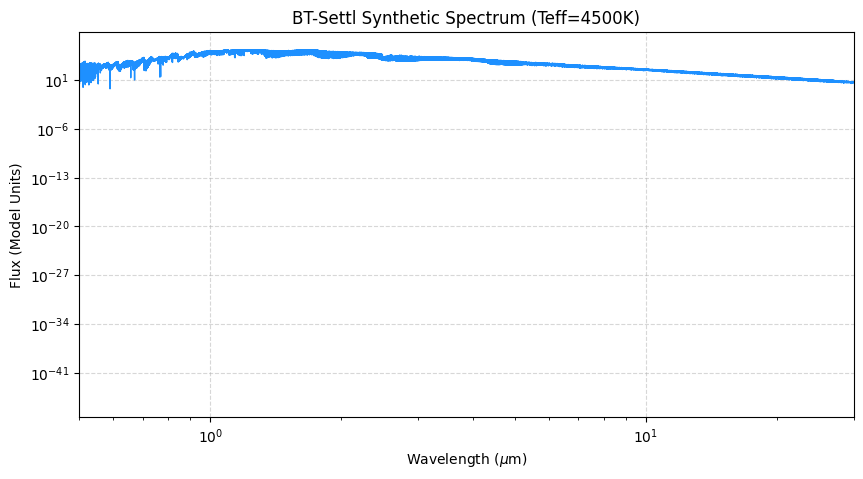

In [30]:
import requests
from astropy.io.votable import parse_single_table
import io
import numpy as np
import matplotlib.pyplot as plt

def fetch_theoretical_spectrum(teff, logg=4.5, z=0.0):
    """
    Fetches the BT-Settl (PHOENIX) theoretical spectrum from the SVO SSAP service.
    """
    # SVO SSAP URL for theoretical models
    ssap_url = "http://svo2.cab.inta-csic.es/theory/newov2/ssap.php"

    # Round Teff to nearest 100 as models are grid-based
    teff_grid = round(teff / 100) * 100

    params = {
        "model": "bt-settl",
        "teff": teff_grid,
        "logg": logg,
        "meta.metallicity": z
    }

    print(f"Querying SVO SSAP for BT-Settl: Teff={teff_grid}K, logg={logg}, [M/H]={z}...")
    response = requests.get(ssap_url, params=params)

    if response.status_code != 200:
        print(f"Failed to reach SVO server. HTTP Status: {response.status_code}")
        return None, None

    try:
        # Check if the content is empty
        if not response.content.strip():
            print("Server returned an empty response.")
            return None, None

        # Parse the VOTable response containing the query results
        votable = parse_single_table(io.BytesIO(response.content))
        if len(votable.array) == 0:
            print("No models found matching the parameters.")
            return None, None

        row = votable.array[0]

        # Find the column containing the download URL (usually 'accref' or similar)
        spectrum_url = None
        for col in votable.array.dtype.names:
            val = row[col]
            if isinstance(val, (str, bytes)):
                val_str = val.decode('utf-8') if isinstance(val, bytes) else val
                if val_str.startswith('http'):
                    spectrum_url = val_str
                    break

        if not spectrum_url:
            print("Could not find a valid download URL in the SVO VOTable.")
            return None, None

        print(f"Spectrum found! Downloading from: {spectrum_url}")
        spec_resp = requests.get(spectrum_url)

        # Parse the actual spectrum VOTable
        spec_table = parse_single_table(io.BytesIO(spec_resp.content))
        col_names = spec_table.array.dtype.names

        # Assuming first column is Wavelength (Angstroms) and second is Flux
        wave_A = spec_table.array[col_names[0]]
        flux_raw = spec_table.array[col_names[1]]

        # Convert Wavelength to microns
        wave_um = wave_A / 10000.0

        return wave_um, flux_raw

    except Exception as e:
        print(f"Error processing SVO response: {e}")
        print(f"Raw server response (first 200 chars): {response.text[:200]}")
        return None, None

# Test the function
test_teff = 4500
wave_model, flux_model = fetch_theoretical_spectrum(teff=test_teff)

if wave_model is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(wave_model, flux_model, color='dodgerblue', linewidth=1)
    plt.xscale('log')
    plt.yscale('log')
    # Focus on the near-IR to mid-IR region relevant to the SED plots
    plt.xlim(0.5, 30)

    plt.xlabel(r'Wavelength ($\mu$m)')
    plt.ylabel('Flux (Model Units)')
    plt.title(f'BT-Settl Synthetic Spectrum (Teff={test_teff}K)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


In [1]:
import pandas as pd

# Load the bulk results generated in the previous step
results_csv_path = '/content/SED_Bulk_Results_v2.csv'
results_df = pd.read_csv(results_csv_path)

# Filter for targets where the dust temperature fit was successful (not NaN)
successful_dust_fits = results_df[results_df['dust_temp'].notna()].copy()

print(f"Total targets processed: {len(results_df)}")
print(f"Targets with a successful dust disk fit: {len(successful_dust_fits)}\n")

# Display the filtered dataframe
display(successful_dust_fits.head(50))

Total targets processed: 5
Targets with a successful dust disk fit: 1



,objid,status,excess_pct,dust_temp,plot_path
1,SSTSL2 J222424.77+602910.6,Processed,13.342311,300.0,/content/SED_plots_v2/SED_SSTSL2_J222424.77_60...


Displaying plot: /content/SED_plots_v2/SED_SSTSL2_J112918.93_203233.8.png


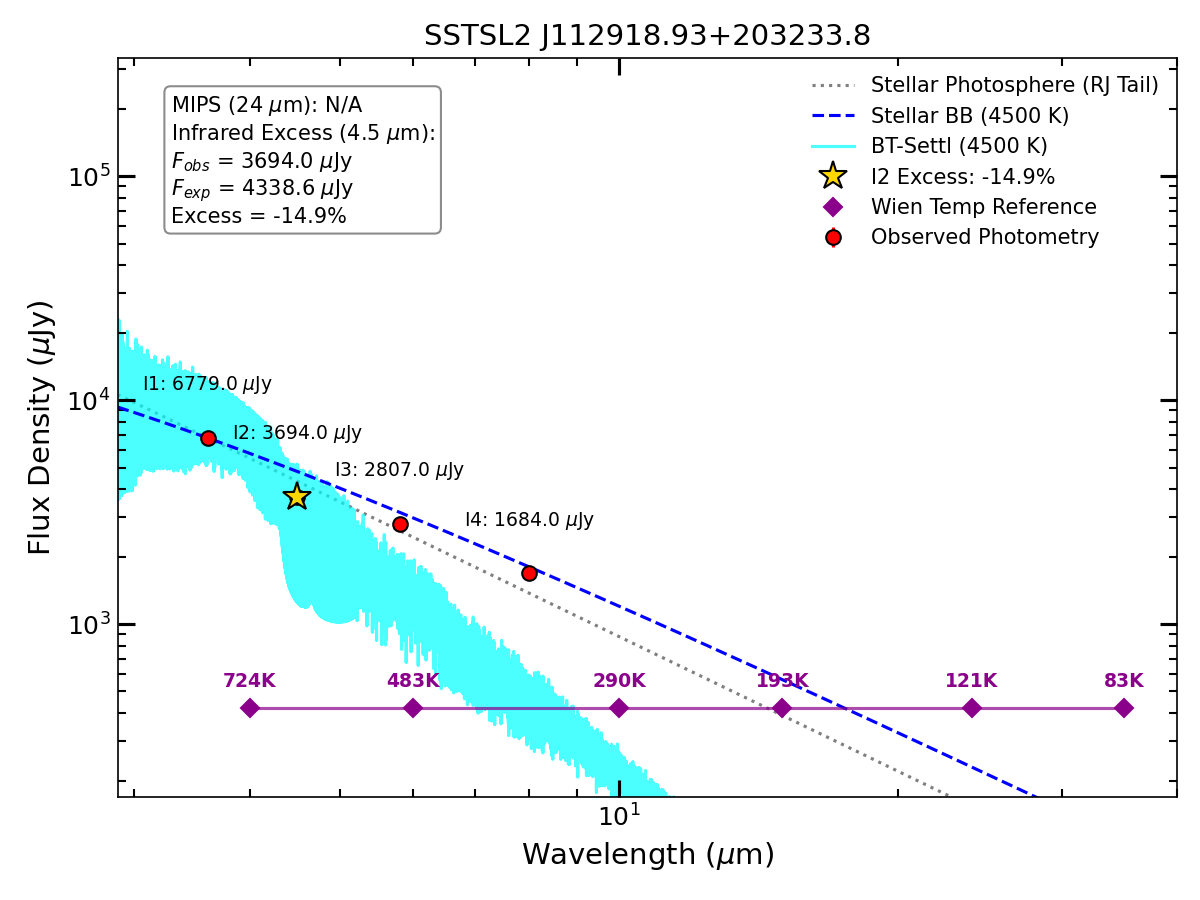

,objid,status,excess_pct,dust_temp,plot_path


In [3]:
from IPython.display import Image, display
import pandas as pd

image_path = '/content/SED_plots_v2/SED_SSTSL2_J112918.93_203233.8.png'

# Display the plot
print(f"Displaying plot: {image_path}")
display(Image(filename=image_path))

# Check the results dataframe to see if a dust disk was fitted
if 'results_df' in locals():
    target_info = results_df[results_df['plot_path'] == image_path]
    display(target_info)
else:
    print("results_df not found in memory.")


In [ ]:
import requests
from astropy.io.votable import parse_single_table
import io

def fetch_theoretical_spectrum(teff, logg=4.5, z=0.0):
    ssap_url = "http://svo2.cab.inta-csic.es/theory/newov2/ssap.php"
    teff_grid = round(teff / 100) * 100
    params = {"model": "bt-settl", "teff": teff_grid, "logg": logg, "meta.metallicity": z}
    try:
        response = requests.get(ssap_url, params=params)
        if response.status_code != 200 or not response.content.strip(): return None, None
        votable = parse_single_table(io.BytesIO(response.content))
        if len(votable.array) == 0: return None, None
        row = votable.array[0]
        spectrum_url = None
        for col in votable.array.dtype.names:
            val = row[col]
            val_str = val.decode('utf-8') if isinstance(val, bytes) else val
            if isinstance(val_str, str) and val_str.startswith('http'):
                spectrum_url = val_str
                break
        if not spectrum_url: return None, None
        spec_resp = requests.get(spectrum_url)
        spec_table = parse_single_table(io.BytesIO(spec_resp.content))
        col_names = spec_table.array.dtype.names
        return spec_table.array[col_names[0]] / 10000.0, spec_table.array[col_names[1]]
    except Exception:
        return None, None

# Re-run the bulk processing for all targets
print("Re-running bulk SED generator to capture all targets...")
run_bulk_sed_generator_updated(
    csv_path='/content/SEIP117k_1k_kdwarfs_filtered.csv',
    output_dir='/content/SED_plots_v2',
    output_csv='/content/SED_Bulk_Results_v2.csv',
    max_targets=None
)
print("Done!")

Re-running bulk SED generator to capture all targets...
STARTING BULK SED GENERATOR (Max Targets: None)

Loaded dataset with 1082 targets. Processing...
Processing target 1: SSTSL2 J122150.00-632440.1
Processing target 2: SSTSL2 J222424.77+602910.6
Processing target 3: SSTSL2 J174731.75+052931.4
Processing target 4: SSTSL2 J010741.41-742546.6
Processing target 5: SSTSL2 J044516.30-680129.1
Processing target 6: SSTSL2 J182727.87-050921.3
Processing target 7: SSTSL2 J043826.46-702456.6
Processing target 8: SSTSL2 J044740.80-684318.4
Processing target 9: SSTSL2 J224016.36+604741.7
Processing target 10: SSTSL2 J162539.59+423833.4
Processing target 11: SSTSL2 J070300.74-033613.8
Processing target 12: SSTSL2 J004953.50-735350.7
Processing target 13: SSTSL2 J015005.23-741931.0
Processing target 14: SSTSL2 J123248.51-705733.5
Processing target 15: SSTSL2 J172425.35+601756.0
Processing target 16: SSTSL2 J021420.97-751903.5
Processing target 17: SSTSL2 J020528.32-744554.5
Processing target 18: S

/tmp/ipykernel_46478/3167809002.py:106: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(dust_model, wavs[residuals > 0], residuals[residuals > 0],


Processing target 42: SSTSL2 J125703.13-791337.6
Processing target 43: SSTSL2 J142639.02-795317.7
Processing target 44: SSTSL2 J060014.31-685101.1
Processing target 45: SSTSL2 J053439.37-655142.3
Processing target 46: SSTSL2 J021648.45-741231.7
Processing target 47: SSTSL2 J055012.63-664340.7
Processing target 48: SSTSL2 J005026.91-713859.8
Processing target 49: SSTSL2 J061105.45-063909.4
Processing target 50: SSTSL2 J141156.27-651032.3


/tmp/ipykernel_46478/3167809002.py:106: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(dust_model, wavs[residuals > 0], residuals[residuals > 0],


Processing target 51: SSTSL2 J132244.94+575806.3
Processing target 52: SSTSL2 J010350.82-710725.5
Processing target 53: SSTSL2 J060224.77-684537.4
Processing target 54: SSTSL2 J172435.04+591212.6
Processing target 55: SSTSL2 J142245.07-795143.6
Processing target 56: SSTSL2 J223811.81+584830.6
Processing target 57: SSTSL2 J172021.28+602012.8
Processing target 58: SSTSL2 J015127.66-734814.6
Processing target 59: SSTSL2 J011141.91-743432.3
Processing target 60: SSTSL2 J162715.42+424016.3
Processing target 61: SSTSL2 J050321.58-652202.3
Processing target 62: SSTSL2 J052202.22-651045.0
Processing target 63: SSTSL2 J050231.83+072712.9
Processing target 64: SSTSL2 J174528.89+052343.3
Processing target 65: SSTSL2 J025613.31+202249.4
Processing target 66: SSTSL2 J083823.73-525732.3
Processing target 67: SSTSL2 J231930.67+002758.8
Processing target 68: SSTSL2 J221139.88+574525.2
Processing target 69: SSTSL2 J052821.74+014100.5
Processing target 70: SSTSL2 J012254.79+072435.5
Processing target 71

...

Processing target 366: SSTSL2 J022657.13-742016.3


/tmp/ipykernel_46478/3167809002.py:106: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(dust_model, wavs[residuals > 0], residuals[residuals > 0],


Processing target 367: SSTSL2 J095031.99+685240.7
Processing target 368: SSTSL2 J045950.23-260252.9
Processing target 369: SSTSL2 J221813.75+585232.4
Processing target 370: SSTSL2 J125817.83+270110.8
Processing target 371: SSTSL2 J012335.33+331440.5
Processing target 372: SSTSL2 J061540.01-061325.5
Processing target 373: SSTSL2 J220821.67+292135.9
Processing target 374: SSTSL2 J105212.44+565730.8
Processing target 375: SSTSL2 J033347.90-272957.4
Processing target 376: SSTSL2 J162526.98+422552.3
Processing target 377: SSTSL2 J064104.46+095318.3
Processing target 378: SSTSL2 J075644.25-385434.2
Processing target 379: SSTSL2 J160214.19-200430.6


/tmp/ipykernel_46478/3167809002.py:106: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(dust_model, wavs[residuals > 0], residuals[residuals > 0],


Processing target 380: SSTSL2 J033427.60-290957.5
Processing target 381: SSTSL2 J121320.87-205313.5
Processing target 382: SSTSL2 J064153.15+095047.4
Processing target 383: SSTSL2 J142644.90+354432.4
Processing target 384: SSTSL2 J054253.60-082022.5
Processing target 385: SSTSL2 J043517.83-683538.8
Processing target 386: SSTSL2 J054343.62-083416.5
Processing target 387: SSTSL2 J053337.49-663433.0
Processing target 388: SSTSL2 J045339.41-030138.5
Processing target 389: SSTSL2 J084214.76-480350.1
Processing target 390: SSTSL2 J224748.89+593122.1
Processing target 391: SSTSL2 J142614.95+342734.7
Processing target 392: SSTSL2 J052804.48-651313.5
Processing target 393: SSTSL2 J050519.92-670838.9
Processing target 394: SSTSL2 J161652.24+555356.1
Processing target 395: SSTSL2 J063933.97+094920.9
